In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import figure
from datetime import datetime, timedelta

from scipy.cluster.hierarchy import centroid
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [60]:
df = pd.read_csv("../data/main_data.csv")

# Clleaning data & formating it

In [61]:
df = df.dropna(subset=["CustomerID"]).copy()

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()
df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"].astype(str).str.replace(",", ".", regex=False),
    errors="raise",
)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

df.info()

/tmp/ipykernel_10056/3062030550.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()


<class 'pandas.DataFrame'>
Index: 392691 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392691 non-null  str           
 1   StockCode    392691 non-null  str           
 2   Description  392691 non-null  str           
 3   Quantity     392691 non-null  int64         
 4   InvoiceDate  392691 non-null  datetime64[us]
 5   UnitPrice    392691 non-null  float64       
 6   CustomerID   392691 non-null  int64         
 7   Country      392691 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.0 MB


In [62]:
nominal = df[["InvoiceDate", "StockCode", "Description","CustomerID", "Country"]]
ordinal = df[["InvoiceDate"]]
discrete = df[["Quantity"]]
continuous = df[["UnitPrice"]]

# Data visualization

### Customers per country

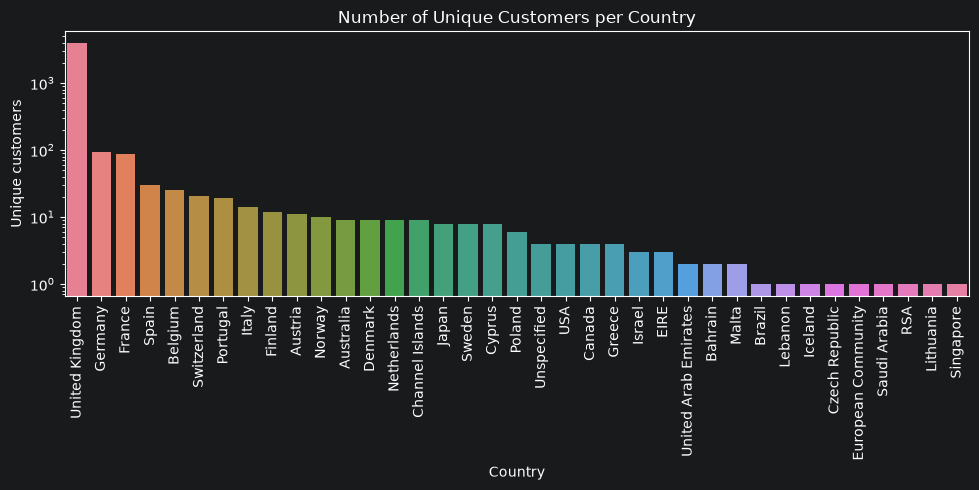

In [63]:
cust_per_country = (
    df.groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_per_country.index, y=cust_per_country.values,
            hue=cust_per_country.index, legend=False)
plt.title("Number of Unique Customers per Country")
plt.ylabel("Unique customers")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log")
plt.show()

### Sales per countery

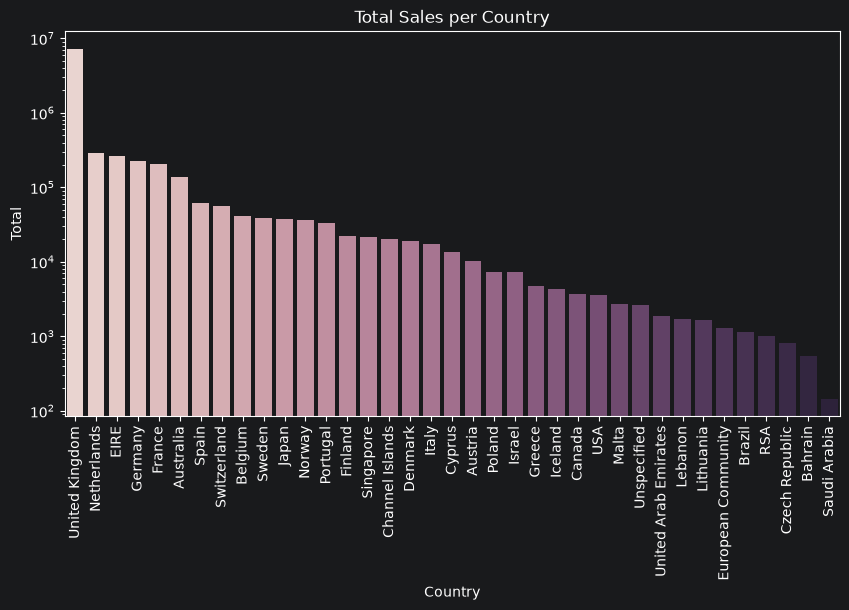

In [64]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

data = (
    df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="Country", y="Total", hue=data.index, legend=False)
plt.xticks(rotation=90)
plt.title("Total Sales per Country")
plt.yscale("log")
plt.show()

# RFM

In [65]:
CRFM = pd.DataFrame(df["CustomerID"].unique(), columns=["CustomerID"])

### Monetary

In [66]:
CRFM = df.groupby("CustomerID")["Total"].sum().rename("Monetary").reset_index()
CRFM

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


### Recency

In [67]:
last_sale = df.groupby("CustomerID")["InvoiceDate"].max()
CRFM["LastSale"] = CRFM["CustomerID"].map(last_sale)

snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
CRFM["Recency"] = (snapshot - CRFM["LastSale"]).dt.days
CRFM.drop(columns=["LastSale"], inplace=True)
CRFM

,CustomerID,Monetary,Recency
0,12346,77183.60,326
1,12347,4310.00,3
2,12348,1797.24,76
3,12349,1757.55,19
4,12350,334.40,311
...,...,...,...
4333,18280,180.60,278
4334,18281,80.82,181
4335,18282,178.05,8
4336,18283,2045.53,4


### Frequency

In [68]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
CRFM["Frequency"] = CRFM["CustomerID"].map(frequency)
CRFM

,CustomerID,Monetary,Recency,Frequency
0,12346,77183.60,326,1
1,12347,4310.00,3,7
2,12348,1797.24,76,4
3,12349,1757.55,19,1
4,12350,334.40,311,1
...,...,...,...,...
4333,18280,180.60,278,1
4334,18281,80.82,181,1
4335,18282,178.05,8,2
4336,18283,2045.53,4,16


# RFM Visualization

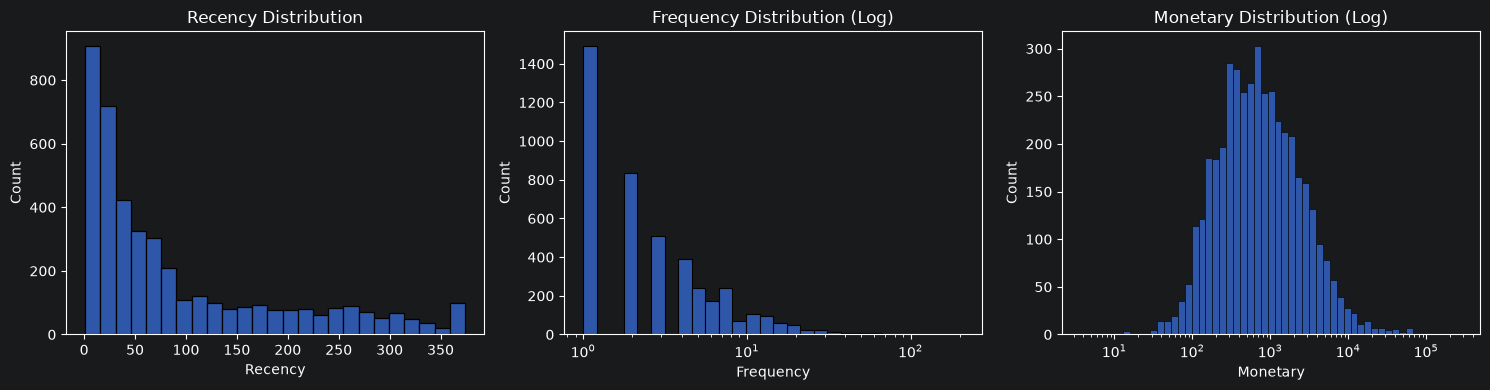

In [69]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

sns.histplot(CRFM["Recency"], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(CRFM["Frequency"], ax=axes[1], log_scale=True)
axes[1].set_title("Frequency Distribution (Log)")

sns.histplot(CRFM["Monetary"], ax=axes[2], log_scale=True)
axes[2].set_title("Monetary Distribution (Log)")

plt.tight_layout()
plt.show()

# Normalisation

In [70]:
# RFM = (CRFM[["Recency", "Frequency", "Monetary"]] - CRFM[["Recency", "Frequency", "Monetary"]].min()) / (CRFM[["Recency", "Frequency", "Monetary"]].max() - CRFM[["Recency", "Frequency", "Monetary"]].min())
# CRFM

# Standariwation

In [71]:
RFM = CRFM[["Monetary", "Frequency", "Recency"]].copy()

RFM["Monetary"] = np.log1p(RFM["Monetary"])
RFM["Frequency"] = np.log1p(RFM["Frequency"])
RFM["Recency"] = np.log1p(RFM["Recency"])

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

RFM = scaler.fit_transform(
    RFM
)
RFM = pd.DataFrame(
    RFM,
    columns=["Monetary", "Frequency", "Recency"]
)

# K-means

## Elbow method

In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from scipy.spatial.distance import cdist
import numpy as np

In [74]:
inertias = []
mapping = {}
K = range(1, 20)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(RFM)

    inertias.append(kmeanModel.inertia_)

    mapping[k] = inertias[-1]

Inertia values:
1 : 13014.000000000004
2 : 6476.523148341361
3 : 4858.66659181913
4 : 3925.4255495726743
5 : 3271.9284474413494
6 : 2852.9970341738062
7 : 2540.281649785781
8 : 2345.91356773933
9 : 2171.2732225014634
10 : 1989.4047090832657
11 : 1861.0425963926257
12 : 1757.797885966765
13 : 1673.3177197744003
14 : 1609.8043823701883
15 : 1503.235121812758
16 : 1471.5248695053797
17 : 1397.777110782214
18 : 1348.0011091480155
19 : 1315.6040789379003


/tmp/ipykernel_10056/178348552.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K, inertias, "bx-",color="red")


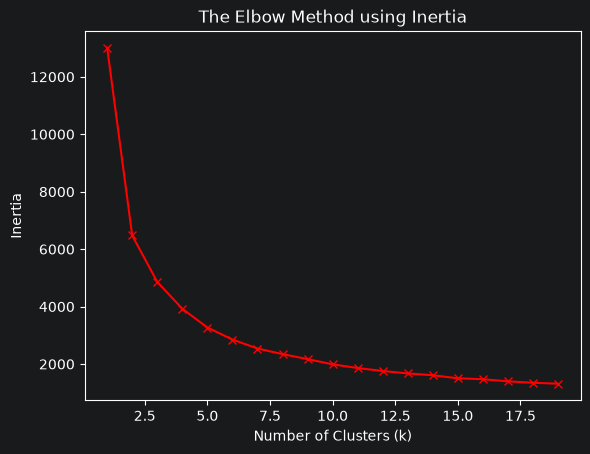

In [75]:
print("Inertia values:")
for key, val in mapping.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, "bx-",color="red")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

### Elbow curve analysis
From the above graph, we can deduce that the best k-means sits between 3 <= k >= 7

## Silouhette score

In [76]:
valid_K = range(2,11)
scors = {}
for k in valid_K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_labels = kmeanModel.fit_predict(RFM)
    scors[k] = silhouette_score(RFM, predicted_labels)

In [77]:
for s in scors:
    print(f"Silhouette score for {s} clusters: {scors[s]}")

Silhouette score for 2 clusters: 0.4325090750300475
Silhouette score for 3 clusters: 0.3362880622386299
Silhouette score for 4 clusters: 0.33290208100066715
Silhouette score for 5 clusters: 0.3180779576712943
Silhouette score for 6 clusters: 0.31287256269668484
Silhouette score for 7 clusters: 0.3102960103848029
Silhouette score for 8 clusters: 0.30206236460749414
Silhouette score for 9 clusters: 0.296020590493119
Silhouette score for 10 clusters: 0.2770785147230721


### Silouhette score analysis
We guessed before that 3 <= k >= 7, but for testing pourpuses, we calculeted the score of (2,11).
The results was close enough to our previous guess, the best score belonged to k = 2 with a score of 0.722

### Difference between the best k (2) and the demanded one (3)
Although 2 was shown to be the best k, 3 would allow an Ecomerce buiseness which our data is from to handdle a more diverse pool of clients, as categorizing people to 3 groups with a right middle left mentality gives more options to make strategies to capture them than a plain either 1 or 2

In [78]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfmPCA = pca.fit_transform(RFM)
KModel = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = KModel.fit_predict(RFM)

CRFM["Cluster"] = labels
rfmPCA

array([[ 0.86441819,  2.70279034],
       [ 2.47639368, -0.6766027 ],
       [ 0.47749699,  0.74722246],
       ...,
       [-0.23697423, -1.68345437],
       [ 2.71744298, -0.51302878],
       [ 0.50545719,  0.30576252]], shape=(4338, 2))

In [79]:
# from sklearn.metrics.pairwise import pairwise_distances_argmin_min
# closest, test = pairwise_distances_argmin_min(KModel.cluster_centers_, rfm)
# test

# Cluster visualization

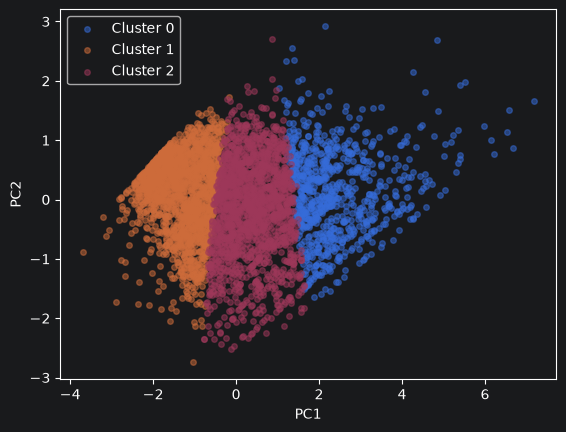

In [80]:
u_labels = np.unique(labels)
for i in u_labels:
    plt.scatter(rfmPCA[labels == i , 0] , rfmPCA[labels == i , 1] , label = f"Cluster {i}", alpha=0.5, s=16)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

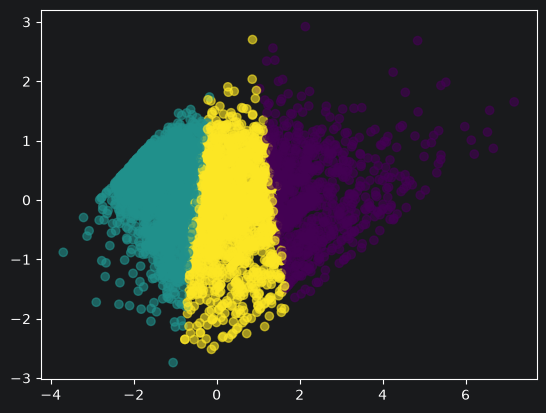

In [81]:
plt.scatter(
    rfmPCA[:,0],
    rfmPCA[:, 1],
    c=CRFM["Cluster"],
    alpha=0.6
)
plt.show()

## RFM Cluster Profiling

In [82]:
stats = CRFM.groupby("Cluster").agg(
    number_of_customers=("Cluster", "size"),
    avg_recency=("Recency", "mean"),
    median_recency=("Recency", "median"),
    avg_frequency=("Frequency", "mean"),
    median_frequency=("Frequency", "median"),
    avg_monetary=("Monetary", "mean"),
    median_monetary=("Monetary", "median"),
    total_revenue=("Monetary", "sum"),
).round(2)
stats.columns = pd.MultiIndex.from_tuples([
    ("Customers", "count"),
    ("Recency", "mean"), ("Recency", "median"),
    ("Frequency", "mean"), ("Frequency", "median"),
    ("Monetary", "mean"), ("Monetary", "median"), ("Monetary", "sum"),
])
stats

Customers Recency        Frequency        Monetary           \
            count    mean median      mean median     mean   median   
Cluster                                                               
0             775   17.97   10.0     13.31   10.0  7879.99  3701.44   
1            1866  168.87  160.0      1.36    1.0   362.51   296.09   
2            1697   43.99   30.0      3.35    3.0  1239.70   962.19   

                     
                sum  
Cluster              
0        6106993.09  
1         676449.08  
2        2103762.82

In [83]:
stats.insert(0, "cluster_name", ["Loyal", "Lost", "Casual"])

In [84]:
stats = stats.reindex([0,2,1])
stats

cluster_name Customers Recency        Frequency        Monetary  \
                         count    mean median      mean median     mean   
Cluster                                                                   
0              Loyal       775   17.97   10.0     13.31   10.0  7879.99   
2             Casual      1697   43.99   30.0      3.35    3.0  1239.70   
1               Lost      1866  168.87  160.0      1.36    1.0   362.51   

                              
          median         sum  
Cluster                       
0        3701.44  6106993.09  
2         962.19  2103762.82  
1         296.09   676449.08

## Clusters observation
From the statistics above, we can easelly see that the 3 clusters are split into:

**Loyal:** Most cutomers, with the lowest recency score, and the highest frequency and monetary gains.

**Lost:** Customers who didn't buy in a long time, who also have the lowest frequency and monetary gains.

**Casual:** these are customers who sit in between, who have practically 2x better scores than the Lost group, with a frequency and monetary gain sitting right in the middle.

In [85]:

# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.cluster import DBSCAN
# from sklearn.neighbors import NearestNeighbors

# min_samples = 6
# dist, _ = NearestNeighbors(n_neighbors=min_samples).fit(RFM).kneighbors(RFM)
# plt.plot(np.sort(dist[:, -1]))
# plt.xlabel("Points (sorted)"); plt.ylabel(f"Distance to {min_samples}th neighbor")
# plt.show()

# db = DBSCAN(eps=0.05, min_samples=min_samples).fit(RFM)
# labels = db.labels_
# n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
# print("Clusters:", n_clusters, "| Noise points:", (labels == -1).sum())
#
# coords = PCA(n_components=2).fit_transform(RFM)
# for lab in sorted(set(labels)):
#     m = labels == lab
#     if lab == -1:
#         plt.scatter(coords[m, 0], coords[m, 1], c="k", marker="x", s=15, label="Noise")
#     else:
#         plt.scatter(coords[m, 0], coords[m, 1], s=15, alpha=0.6, label=f"Cluster {lab}")
# plt.title(f"DBSCAN: {n_clusters} clusters")
# plt.legend(); plt.show()
#
# mask = labels != -1
# if n_clusters >= 2:
#     print("Silhouette (no noise):", silhouette_score(RFM[mask], labels[mask]))